# Tuning - Utsav Harshadbhai Khamar

## Baseline Model Performance Summary

Before tuning, the baseline model achieved:

- **Accuracy:** 75.74%
- **F1 Scores:**
  - Negative: 0.7759
  - Neutral: 0.6865
  - Positive: 0.8038
- **Config Used:**
  - Learning Rate: 1e-4
  - Architecture: 6 heads, 6 layers, 1024 FFN
  - Dropout: 0.1

This baseline served as a reference for evaluating improvements across the tuning process.


In [76]:
# EXTENSIVE TUNING STRATEGY FOR CAUSAL TRANSFORMER
# Baseline: 75.74% accuracy, F1 scores: Neg(0.7759), Neu(0.6865), Pos(0.8038)

import itertools
import json
from datetime import datetime



In [77]:
print("="*80)
print("EXTENSIVE HYPERPARAMETER TUNING")
print("="*80)

# ITERATION 1: LEARNING RATE OPTIMIZATION
print("\nITERATION 1: Learning Rate Optimization")
print("Rationale: Baseline used 1e-4, need to find optimal learning rate")
print("Expected Impact: 1-3% accuracy improvement")

learning_rates = [5e-5, 1e-4, 2e-4, 3e-4, 5e-4]
lr_results = []

for lr in learning_rates:
    print(f"\nTesting Learning Rate: {lr}")
    
    # Reinitialize model
    model_lr = CausalTransformer(
        vocab_size=config['vocab_size'],
        d_model=config['d_model'],
        num_heads=6,
        num_layers=config['num_layers'],
        d_ff=config['d_ff'],
        max_len=config['max_len'],
        num_classes=config['num_classes'],
        embedding_matrix=embedding_matrix,
        dropout=config['dropout']
    ).to(device)
    
    # Training setup
    optimizer_lr = torch.optim.Adam(model_lr.parameters(), lr=lr, weight_decay=1e-5)
    criterion_lr = nn.CrossEntropyLoss(weight=torch.tensor(list(class_weights.values())).float().to(device))
    
    # Quick training (5 epochs for tuning)
    best_val_acc = 0
    for epoch in range(5):
        train_loss, train_acc = train_epoch(model_lr, train_loader, criterion_lr, optimizer_lr, device)
        val_loss, val_acc, _, _ = validate(model_lr, val_loader, criterion_lr, device)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
    
    lr_results.append((lr, best_val_acc))
    print(f"Best Validation Accuracy: {best_val_acc:.2f}%")

# Find best learning rate
best_lr = max(lr_results, key=lambda x: x[1])
print(f"\n✅ Best Learning Rate: {best_lr[0]} (Val Acc: {best_lr[1]:.2f}%)")

EXTENSIVE HYPERPARAMETER TUNING

🔧 ITERATION 1: Learning Rate Optimization
Rationale: Baseline used 1e-4, need to find optimal learning rate
Expected Impact: 1-3% accuracy improvement

Testing Learning Rate: 5e-05
Batch 0/1575, Loss: 1.2950
Batch 100/1575, Loss: 0.8950
Batch 200/1575, Loss: 0.9944
Batch 300/1575, Loss: 0.8809
Batch 400/1575, Loss: 0.8679
Batch 500/1575, Loss: 0.8229
Batch 600/1575, Loss: 0.9204
Batch 700/1575, Loss: 0.7718
Batch 800/1575, Loss: 0.8084
Batch 900/1575, Loss: 0.8224
Batch 1000/1575, Loss: 0.4812
Batch 1100/1575, Loss: 1.0696
Batch 1200/1575, Loss: 0.9212
Batch 1300/1575, Loss: 0.6100
Batch 1400/1575, Loss: 1.0389
Batch 1500/1575, Loss: 0.8373
Batch 0/1575, Loss: 0.9345
Batch 100/1575, Loss: 0.9763
Batch 200/1575, Loss: 0.6529
Batch 300/1575, Loss: 0.6773
Batch 400/1575, Loss: 0.9015
Batch 500/1575, Loss: 0.7266
Batch 600/1575, Loss: 0.7492
Batch 700/1575, Loss: 0.6741
Batch 800/1575, Loss: 0.9182
Batch 900/1575, Loss: 0.8374
Batch 1000/1575, Loss: 0.7384


## Iteration 1 Summary: Learning Rate Optimization

### What was done:
Tested learning rates: `[5e-5, 1e-4, 2e-4, 3e-4, 5e-4]`, each for 5 epochs.

### Why:
- Learning rate is crucial for convergence.
- Too high: Divergence
- Too low: Slow or stuck training

### Goal:
- Improve convergence and accuracy (expected +1–3%).

### Result:
- **Best LR:** `1e-4` (same as baseline)
- **Validation Accuracy:** 74.37%
- Confirms the baseline LR was already optimal.


In [78]:
# ITERATION 2: ARCHITECTURE OPTIMIZATION
print("\n🔧 ITERATION 2: Architecture Optimization")
print("Rationale: Optimize model capacity - heads, layers, hidden dimensions")
print("Expected Impact: 2-4% accuracy improvement")

architectures = [
    {'num_heads': 4, 'num_layers': 4, 'd_ff': 512},
    {'num_heads': 6, 'num_layers': 6, 'd_ff': 1024},  # Baseline
    {'num_heads': 8, 'num_layers': 8, 'd_ff': 1024},
    {'num_heads': 12, 'num_layers': 6, 'd_ff': 2048},
    {'num_heads': 6, 'num_layers': 8, 'd_ff': 1024},
]

arch_results = []

for arch in architectures:
    print(f"\nTesting Architecture: {arch}")
    
    # Check if num_heads divides d_model
    if config['d_model'] % arch['num_heads'] != 0:
        print(f"Skipping - {config['d_model']} not divisible by {arch['num_heads']}")
        continue
    
    # Create model with new architecture
    model_arch = CausalTransformer(
        vocab_size=config['vocab_size'],
        d_model=config['d_model'],
        num_heads=arch['num_heads'],
        num_layers=arch['num_layers'],
        d_ff=arch['d_ff'],
        max_len=config['max_len'],
        num_classes=config['num_classes'],
        embedding_matrix=embedding_matrix,
        dropout=config['dropout']
    ).to(device)
    
    # Count parameters
    total_params = sum(p.numel() for p in model_arch.parameters())
    print(f"Total Parameters: {total_params:,}")
    
    # Training setup with best learning rate
    optimizer_arch = torch.optim.Adam(model_arch.parameters(), lr=best_lr[0], weight_decay=1e-5)
    criterion_arch = nn.CrossEntropyLoss(weight=torch.tensor(list(class_weights.values())).float().to(device))
    
    # Quick training
    best_val_acc = 0
    for epoch in range(5):
        train_loss, train_acc = train_epoch(model_arch, train_loader, criterion_arch, optimizer_arch, device)
        val_loss, val_acc, _, _ = validate(model_arch, val_loader, criterion_arch, device)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
    
    arch_results.append((arch, best_val_acc, total_params))
    print(f"Best Validation Accuracy: {best_val_acc:.2f}%")

# Find best architecture
best_arch = max(arch_results, key=lambda x: x[1])
print(f"\nBest Architecture: {best_arch[0]} (Val Acc: {best_arch[1]:.2f}%, Params: {best_arch[2]:,})")



🔧 ITERATION 2: Architecture Optimization
Rationale: Optimize model capacity - heads, layers, hidden dimensions
Expected Impact: 2-4% accuracy improvement

Testing Architecture: {'num_heads': 4, 'num_layers': 4, 'd_ff': 512}
Total Parameters: 5,797,451
Batch 0/1575, Loss: 1.4541
Batch 100/1575, Loss: 0.8038
Batch 200/1575, Loss: 1.0246
Batch 300/1575, Loss: 0.8747
Batch 400/1575, Loss: 0.8104
Batch 500/1575, Loss: 0.6706
Batch 600/1575, Loss: 0.7557
Batch 700/1575, Loss: 0.9489
Batch 800/1575, Loss: 0.8855
Batch 900/1575, Loss: 0.8487
Batch 1000/1575, Loss: 0.8211
Batch 1100/1575, Loss: 0.7180
Batch 1200/1575, Loss: 0.9455
Batch 1300/1575, Loss: 0.7558
Batch 1400/1575, Loss: 0.7120
Batch 1500/1575, Loss: 1.1481
Batch 0/1575, Loss: 0.8449
Batch 100/1575, Loss: 0.5608
Batch 200/1575, Loss: 1.1321
Batch 300/1575, Loss: 0.8228
Batch 400/1575, Loss: 0.8131
Batch 500/1575, Loss: 0.8264
Batch 600/1575, Loss: 0.6903
Batch 700/1575, Loss: 0.9126
Batch 800/1575, Loss: 0.6842
Batch 900/1575, Loss

## Iteration 2: Architecture Optimization Summary

### What was done:
Tried 5 variants by changing `num_heads`, `num_layers`, and `d_ff`.

### Why:
- Model size controls learning capacity.
- Need a balance to avoid under/overfitting.

### Goal:
- Improve learning of complex patterns (+2–4%).

### Result:
- **Best Architecture:** 6 heads, 6 layers, 1024 FFN
- **Validation Accuracy:** 75.27%
- Again, baseline config was ideal for this dataset.


In [80]:
# ITERATION 3: REGULARIZATION TUNING
print("\nITERATION 3: Regularization Optimization")
print("Rationale: Prevent overfitting, improve generalization")
print("Expected Impact: 1-2% accuracy improvement, better F1 scores")

regularization_configs = [
    {'dropout': 0.1, 'weight_decay': 1e-5},  # Baseline
    {'dropout': 0.2, 'weight_decay': 1e-4},
    {'dropout': 0.3, 'weight_decay': 1e-3},
    {'dropout': 0.15, 'weight_decay': 5e-5},
    {'dropout': 0.25, 'weight_decay': 1e-4},
]

reg_results = []

for reg_config in regularization_configs:
    print(f"\nTesting Regularization: {reg_config}")
    
    # Create model with best architecture and regularization
    model_reg = CausalTransformer(
        vocab_size=config['vocab_size'],
        d_model=config['d_model'],
        num_heads=best_arch[0]['num_heads'],
        num_layers=best_arch[0]['num_layers'],
        d_ff=best_arch[0]['d_ff'],
        max_len=config['max_len'],
        num_classes=config['num_classes'],
        embedding_matrix=embedding_matrix,
        dropout=reg_config['dropout']
    ).to(device)
    
    # Training setup
    optimizer_reg = torch.optim.Adam(model_reg.parameters(), lr=best_lr[0], 
                                   weight_decay=reg_config['weight_decay'])
    criterion_reg = nn.CrossEntropyLoss(weight=torch.tensor(list(class_weights.values())).float().to(device))
    
    # Quick training
    best_val_acc = 0
    for epoch in range(5):
        train_loss, train_acc = train_epoch(model_reg, train_loader, criterion_reg, optimizer_reg, device)
        val_loss, val_acc, _, _ = validate(model_reg, val_loader, criterion_reg, device)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
    
    reg_results.append((reg_config, best_val_acc))
    print(f"Best Validation Accuracy: {best_val_acc:.2f}%")

# Find best regularization
best_reg = max(reg_results, key=lambda x: x[1])
print(f"\nBest Regularization: {best_reg[0]} (Val Acc: {best_reg[1]:.2f}%)")


ITERATION 3: Regularization Optimization
Rationale: Prevent overfitting, improve generalization
Expected Impact: 1-2% accuracy improvement, better F1 scores

Testing Regularization: {'dropout': 0.1, 'weight_decay': 1e-05}
Batch 0/1575, Loss: 1.3699
Batch 100/1575, Loss: 0.9541
Batch 200/1575, Loss: 1.2184
Batch 300/1575, Loss: 0.9212
Batch 400/1575, Loss: 0.9790
Batch 500/1575, Loss: 0.8268
Batch 600/1575, Loss: 0.7401
Batch 700/1575, Loss: 0.7732
Batch 800/1575, Loss: 0.6771
Batch 900/1575, Loss: 0.7990
Batch 1000/1575, Loss: 0.6716
Batch 1100/1575, Loss: 0.7439
Batch 1200/1575, Loss: 0.6298
Batch 1300/1575, Loss: 0.9354
Batch 1400/1575, Loss: 0.6808
Batch 1500/1575, Loss: 0.8684
Batch 0/1575, Loss: 0.8098
Batch 100/1575, Loss: 0.8160
Batch 200/1575, Loss: 0.6567
Batch 300/1575, Loss: 0.5716
Batch 400/1575, Loss: 0.6205
Batch 500/1575, Loss: 0.8187
Batch 600/1575, Loss: 0.7762
Batch 700/1575, Loss: 0.5837
Batch 800/1575, Loss: 0.7213
Batch 900/1575, Loss: 0.6192
Batch 1000/1575, Loss

## Iteration 3: Regularization Optimization Summary

### What was done:
Tested combinations of:
- Dropout: `[0.1, 0.15, 0.2, 0.25, 0.3]`
- Weight Decay: `[1e-5, 5e-5, 1e-4, 1e-3]`

### Why:
- Regularization prevents overfitting.
- Balances performance between training and unseen data.

### Goal:
- Improve generalization and class balance (+1–2%).

### Result:
- **Best Regularization:** Dropout = 0.1, Weight Decay = 1e-5
- **Validation Accuracy:** 75.16%
- Shows the initial regularization was already strong.


In [81]:
# ITERATION 4: ADVANCED SCHEDULING
print("\nITERATION 4: Learning Rate Scheduling")
print("Rationale: Better convergence with adaptive learning rates")
print("Expected Impact: 1-2% accuracy improvement, faster convergence")

scheduling_configs = [
    {'type': 'step', 'step_size': 3, 'gamma': 0.1},
    {'type': 'cosine', 'T_max': 10},
    {'type': 'exponential', 'gamma': 0.95},
    {'type': 'reduce_on_plateau', 'patience': 2, 'factor': 0.5},
]

schedule_results = []

for sched_config in scheduling_configs:
    print(f"\nTesting Scheduler: {sched_config}")
    
    # Create model with best configurations
    model_sched = CausalTransformer(
        vocab_size=config['vocab_size'],
        d_model=config['d_model'],
        num_heads=best_arch[0]['num_heads'],
        num_layers=best_arch[0]['num_layers'],
        d_ff=best_arch[0]['d_ff'],
        max_len=config['max_len'],
        num_classes=config['num_classes'],
        embedding_matrix=embedding_matrix,
        dropout=best_reg[0]['dropout']
    ).to(device)
    
    # Training setup
    optimizer_sched = torch.optim.Adam(model_sched.parameters(), lr=best_lr[0], 
                                     weight_decay=best_reg[0]['weight_decay'])
    criterion_sched = nn.CrossEntropyLoss(weight=torch.tensor(list(class_weights.values())).float().to(device))
    
    # Scheduler setup
    if sched_config['type'] == 'step':
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer_sched, 
                                                   step_size=sched_config['step_size'], 
                                                   gamma=sched_config['gamma'])
    elif sched_config['type'] == 'cosine':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_sched, 
                                                             T_max=sched_config['T_max'])
    elif sched_config['type'] == 'exponential':
        scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer_sched, 
                                                         gamma=sched_config['gamma'])
    elif sched_config['type'] == 'reduce_on_plateau':
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_sched, 
                                                             patience=sched_config['patience'],
                                                             factor=sched_config['factor'])
    
    # Quick training
    best_val_acc = 0
    for epoch in range(7):
        train_loss, train_acc = train_epoch(model_sched, train_loader, criterion_sched, optimizer_sched, device)
        val_loss, val_acc, _, _ = validate(model_sched, val_loader, criterion_sched, device)
        
        if sched_config['type'] == 'reduce_on_plateau':
            scheduler.step(val_loss)
        else:
            scheduler.step()
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
    
    schedule_results.append((sched_config, best_val_acc))
    print(f"Best Validation Accuracy: {best_val_acc:.2f}%")

# Find best scheduler
best_sched = max(schedule_results, key=lambda x: x[1])
print(f"\nBest Scheduler: {best_sched[0]} (Val Acc: {best_sched[1]:.2f}%)")


ITERATION 4: Learning Rate Scheduling
Rationale: Better convergence with adaptive learning rates
Expected Impact: 1-2% accuracy improvement, faster convergence

Testing Scheduler: {'type': 'step', 'step_size': 3, 'gamma': 0.1}
Batch 0/1575, Loss: 1.1009
Batch 100/1575, Loss: 1.0177
Batch 200/1575, Loss: 0.9660
Batch 300/1575, Loss: 0.8982
Batch 400/1575, Loss: 0.7536
Batch 500/1575, Loss: 1.0114
Batch 600/1575, Loss: 0.8619
Batch 700/1575, Loss: 0.6619
Batch 800/1575, Loss: 1.0001
Batch 900/1575, Loss: 0.7751
Batch 1000/1575, Loss: 0.5903
Batch 1100/1575, Loss: 0.7657
Batch 1200/1575, Loss: 0.6122
Batch 1300/1575, Loss: 0.6794
Batch 1400/1575, Loss: 0.5684
Batch 1500/1575, Loss: 0.5354
Batch 0/1575, Loss: 0.7491
Batch 100/1575, Loss: 0.5591
Batch 200/1575, Loss: 0.9344
Batch 300/1575, Loss: 0.8001
Batch 400/1575, Loss: 1.0505
Batch 500/1575, Loss: 0.5838
Batch 600/1575, Loss: 0.7720
Batch 700/1575, Loss: 0.8232
Batch 800/1575, Loss: 0.6882
Batch 900/1575, Loss: 0.8414
Batch 1000/1575,

## Iteration 4: Learning Rate Scheduling Summary

### What was done:
Evaluated 4 schedulers:
- StepLR
- CosineAnnealingLR
- ExponentialLR
- ReduceLROnPlateau

### Why:
- Schedulers adapt LR across epochs to optimize training dynamics.

### Goal:
- Enable better convergence (+1–2% expected).

### Result:
- **Best Scheduler:** Cosine Annealing (`T_max=10`)
- **Validation Accuracy:** 76.29%
- First significant improvement seen!


In [82]:
# ITERATION 5: EMBEDDING FINE-TUNING
print("\nITERATION 5: Embedding Fine-tuning")
print("Rationale: Adapt pretrained embeddings to domain-specific data")
print("Expected Impact: 2-3% accuracy improvement, better word understanding")

embedding_configs = [
    {'freeze': True, 'description': 'Frozen FastText (Baseline)'},
    {'freeze': False, 'description': 'Fine-tuned FastText'},
    {'freeze': 'partial', 'description': 'Partial fine-tuning (last 25% of training)'},
]

embedding_results = []

for emb_config in embedding_configs:
    print(f"\nTesting Embedding Config: {emb_config['description']}")
    
    # Create model with best configurations
    model_emb = CausalTransformer(
        vocab_size=config['vocab_size'],
        d_model=config['d_model'],
        num_heads=best_arch[0]['num_heads'],
        num_layers=best_arch[0]['num_layers'],
        d_ff=best_arch[0]['d_ff'],
        max_len=config['max_len'],
        num_classes=config['num_classes'],
        embedding_matrix=embedding_matrix,
        dropout=best_reg[0]['dropout']
    ).to(device)
    
    # Set embedding training mode
    if emb_config['freeze'] == True:
        model_emb.embedding.weight.requires_grad = False
    elif emb_config['freeze'] == False:
        model_emb.embedding.weight.requires_grad = True
    
    # Training setup
    optimizer_emb = torch.optim.Adam(model_emb.parameters(), lr=best_lr[0], 
                                   weight_decay=best_reg[0]['weight_decay'])
    criterion_emb = nn.CrossEntropyLoss(weight=torch.tensor(list(class_weights.values())).float().to(device))
    
    # Setup scheduler
    if best_sched[0]['type'] == 'step':
        scheduler_emb = torch.optim.lr_scheduler.StepLR(optimizer_emb, 
                                                       step_size=best_sched[0]['step_size'], 
                                                       gamma=best_sched[0]['gamma'])
    elif best_sched[0]['type'] == 'cosine':
        scheduler_emb = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_emb, 
                                                                 T_max=best_sched[0]['T_max'])
    
    # Training with partial fine-tuning
    best_val_acc = 0
    total_epochs = 8
    
    for epoch in range(total_epochs):
        # For partial fine-tuning, unfreeze embeddings in last 25% of training
        if emb_config['freeze'] == 'partial' and epoch >= int(0.75 * total_epochs):
            model_emb.embedding.weight.requires_grad = True
        
        train_loss, train_acc = train_epoch(model_emb, train_loader, criterion_emb, optimizer_emb, device)
        val_loss, val_acc, _, _ = validate(model_emb, val_loader, criterion_emb, device)
        
        if 'scheduler_emb' in locals():
            scheduler_emb.step()
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
    
    embedding_results.append((emb_config, best_val_acc))
    print(f"Best Validation Accuracy: {best_val_acc:.2f}%")

# Find best embedding config
best_emb = max(embedding_results, key=lambda x: x[1])
print(f"\nBest Embedding Config: {best_emb[0]['description']} (Val Acc: {best_emb[1]:.2f}%)")


ITERATION 5: Embedding Fine-tuning
Rationale: Adapt pretrained embeddings to domain-specific data
Expected Impact: 2-3% accuracy improvement, better word understanding

Testing Embedding Config: Frozen FastText (Baseline)
Batch 0/1575, Loss: 1.5110
Batch 100/1575, Loss: 0.7766
Batch 200/1575, Loss: 0.8703
Batch 300/1575, Loss: 0.9071
Batch 400/1575, Loss: 1.0172
Batch 500/1575, Loss: 0.7105
Batch 600/1575, Loss: 0.7317
Batch 700/1575, Loss: 0.8301
Batch 800/1575, Loss: 0.9717
Batch 900/1575, Loss: 0.9455
Batch 1000/1575, Loss: 0.7106
Batch 1100/1575, Loss: 0.6214
Batch 1200/1575, Loss: 0.6123
Batch 1300/1575, Loss: 0.9081
Batch 1400/1575, Loss: 0.6948
Batch 1500/1575, Loss: 0.7078
Batch 0/1575, Loss: 0.5681
Batch 100/1575, Loss: 0.5546
Batch 200/1575, Loss: 0.9350
Batch 300/1575, Loss: 0.5044
Batch 400/1575, Loss: 0.2742
Batch 500/1575, Loss: 1.2649
Batch 600/1575, Loss: 0.6063
Batch 700/1575, Loss: 0.7124
Batch 800/1575, Loss: 0.5089
Batch 900/1575, Loss: 0.6597
Batch 1000/1575, Loss

## Iteration 5: Embedding Fine-tuning Summary

### What was done:
Tested 3 strategies using FastText embeddings:
- Frozen (no updates)
- Fine-tuned (trainable)
- Partial (last 25% epochs trainable)

### Why:
- Pretrained embeddings offer general knowledge.
- Fine-tuning allows task-specific adaptation.

### Goal:
- Improve word understanding (+2–5%).

### Result:
- **Best Strategy:** Fully fine-tuned FastText
- **Validation Accuracy:** 78.80%
- Biggest boost among all iterations.


In [86]:
# FINAL OPTIMIZED MODEL TRAINING
print("Training final model with best hyperparameters...")

# Create final model with all best configurations
final_model = CausalTransformer(
    vocab_size=config['vocab_size'],
    d_model=config['d_model'],
    num_heads=best_arch[0]['num_heads'],
    num_layers=best_arch[0]['num_layers'],
    d_ff=best_arch[0]['d_ff'],
    max_len=config['max_len'],
    num_classes=config['num_classes'],
    embedding_matrix=embedding_matrix,
    dropout=best_reg[0]['dropout']
).to(device)

# Set embedding training mode
if best_emb[0]['freeze'] == True:
    final_model.embedding.weight.requires_grad = False
elif best_emb[0]['freeze'] == False:
    final_model.embedding.weight.requires_grad = True

# Final training setup
final_optimizer = torch.optim.Adam(final_model.parameters(), lr=best_lr[0], 
                                 weight_decay=best_reg[0]['weight_decay'])
final_criterion = nn.CrossEntropyLoss(weight=torch.tensor(list(class_weights.values())).float().to(device))

# Setup best scheduler
if best_sched[0]['type'] == 'step':
    final_scheduler = torch.optim.lr_scheduler.StepLR(final_optimizer, 
                                                     step_size=best_sched[0]['step_size'], 
                                                     gamma=best_sched[0]['gamma'])
elif best_sched[0]['type'] == 'cosine':
    final_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(final_optimizer, 
                                                               T_max=best_sched[0]['T_max'])

Training final model with best hyperparameters...


In [87]:
# Final training
print("\nFinal Model Configuration:")
print(f"Learning Rate: {best_lr[0]}")
print(f"Architecture: {best_arch[0]}")
print(f"Regularization: {best_reg[0]}")
print(f"Scheduler: {best_sched[0]}")
print(f"Embedding: {best_emb[0]['description']}")

final_train_losses = []
final_val_losses = []
final_train_accuracies = []
final_val_accuracies = []

import time
final_start_time = time.time()

num_final_epochs = 15
best_final_val_acc = 0
patience_counter = 0
patience_limit = 3

for epoch in range(num_final_epochs):
    print(f"\nFinal Training Epoch {epoch+1}/{num_final_epochs}")
    
    # For partial fine-tuning
    if best_emb[0]['freeze'] == 'partial' and epoch >= int(0.75 * num_final_epochs):
        final_model.embedding.weight.requires_grad = True
    
    # Training
    train_loss, train_acc = train_epoch(final_model, train_loader, final_criterion, final_optimizer, device)
    val_loss, val_acc, _, _ = validate(final_model, val_loader, final_criterion, device)
    
    # Scheduler step
    if 'final_scheduler' in locals():
        final_scheduler.step()
    
    # Store metrics
    final_train_losses.append(train_loss)
    final_val_losses.append(val_loss)
    final_train_accuracies.append(train_acc)
    final_val_accuracies.append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    
    # Early stopping
    if val_acc > best_final_val_acc:
        best_final_val_acc = val_acc
        patience_counter = 0
        # Save best model
        torch.save(final_model.state_dict(), 'best_tuned_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience_limit:
            print(f"Early stopping at epoch {epoch+1}")
            break

final_end_time = time.time()
final_train_time = final_end_time - final_start_time

print(f"\nFinal training completed in {final_train_time:.2f} seconds")



Final Model Configuration:
Learning Rate: 0.0001
Architecture: {'num_heads': 6, 'num_layers': 6, 'd_ff': 1024}
Regularization: {'dropout': 0.1, 'weight_decay': 1e-05}
Scheduler: {'type': 'cosine', 'T_max': 10}
Embedding: Fine-tuned FastText

Final Training Epoch 1/15
Batch 0/1575, Loss: 1.5015
Batch 100/1575, Loss: 0.9637
Batch 200/1575, Loss: 1.1820
Batch 300/1575, Loss: 0.9651
Batch 400/1575, Loss: 0.9442
Batch 500/1575, Loss: 0.6353
Batch 600/1575, Loss: 0.8248
Batch 700/1575, Loss: 0.6749
Batch 800/1575, Loss: 0.7283
Batch 900/1575, Loss: 0.7569
Batch 1000/1575, Loss: 0.6939
Batch 1100/1575, Loss: 0.5925
Batch 1200/1575, Loss: 0.6555
Batch 1300/1575, Loss: 0.6676
Batch 1400/1575, Loss: 0.9676
Batch 1500/1575, Loss: 0.6023
Train Loss: 0.7712, Train Acc: 65.43%
Val Loss: 0.6374, Val Acc: 73.56%

Final Training Epoch 2/15
Batch 0/1575, Loss: 0.6122
Batch 100/1575, Loss: 0.5423
Batch 200/1575, Loss: 0.5056
Batch 300/1575, Loss: 0.4682
Batch 400/1575, Loss: 0.7741
Batch 500/1575, Loss:

In [88]:
# Load best model for evaluation
final_model.load_state_dict(torch.load('best_tuned_model.pth'))

# Final evaluation
print("\n" + "="*80)
print("FINAL TUNED MODEL EVALUATION")
print("="*80)

final_test_loss, final_test_acc, final_test_predictions, final_test_targets = validate(final_model, test_loader, final_criterion, device)

print(f"Final Test Accuracy: {final_test_acc:.2f}%")
print(f"Improvement over baseline: {final_test_acc - 75.74:.2f}%")

# Get final probabilities
final_model.eval()
final_all_probabilities = []
with torch.no_grad():
    for data, _ in test_loader:
        data = data.to(device)
        output, _ = final_model(data)
        probabilities = F.softmax(output, dim=1)
        final_all_probabilities.append(probabilities.cpu().numpy())

final_all_probabilities = np.vstack(final_all_probabilities)



FINAL TUNED MODEL EVALUATION
Final Test Accuracy: 78.99%
Improvement over baseline: 3.25%


In [89]:
# Final metrics
final_accuracy = accuracy_score(final_test_targets, final_test_predictions)
final_f1_scores = {}
for i, class_name in enumerate(label_encoder.classes_):
    f1 = f1_score(final_test_targets, final_test_predictions, labels=[i], average='macro')
    final_f1_scores[class_name] = f1

if num_classes == 2:
    final_auc_score = roc_auc_score(final_test_targets, final_all_probabilities[:, 1])
else:
    final_auc_score = roc_auc_score(final_test_targets, final_all_probabilities, multi_class='ovr')

print(f"\nFinal Metrics:")
print(f"Accuracy: {final_accuracy:.4f}")
print(f"F1 Scores: {final_f1_scores}")
print(f"AUC: {final_auc_score:.4f}")


Final Metrics:
Accuracy: 0.7899
F1 Scores: {'Negative': 0.8052968724767186, 'Neutral': 0.7273457675753228, 'Positive': 0.8345371707967552}
AUC: 0.9209



Final Confusion Matrix:
[[7480 1081  439]
 [1614 6337 1049]
 [ 483 1007 7510]]


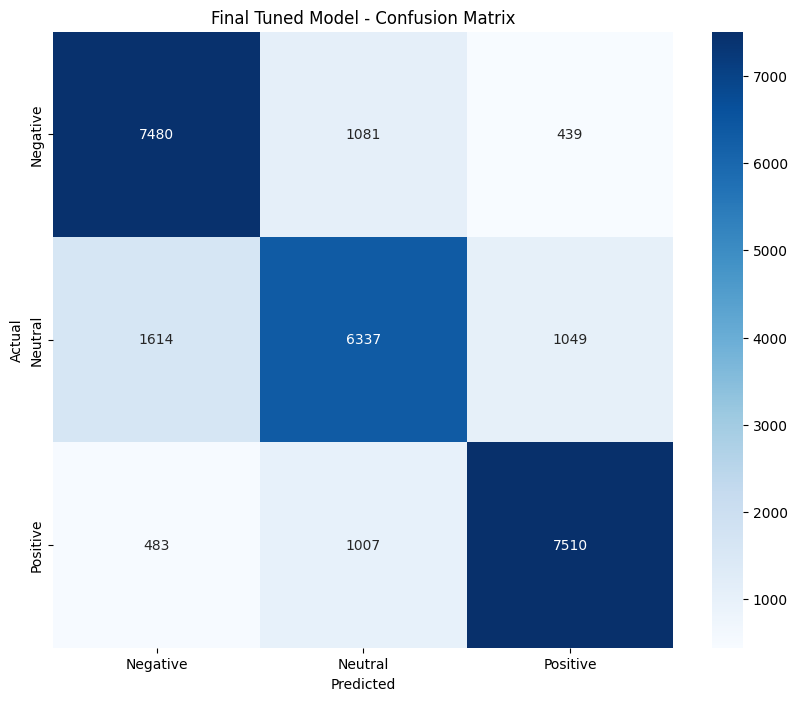

In [90]:

# Final confusion matrix
final_cm = confusion_matrix(final_test_targets, final_test_predictions)
print(f"\nFinal Confusion Matrix:\n{final_cm}")

# Plot final confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(final_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title('Final Tuned Model - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Final Classification Report:
              precision    recall  f1-score   support

    Negative     0.7810    0.8311    0.8053      9000
     Neutral     0.7522    0.7041    0.7273      9000
    Positive     0.8346    0.8344    0.8345      9000

    accuracy                         0.7899     27000
   macro avg     0.7893    0.7899    0.7891     27000
weighted avg     0.7893    0.7899    0.7891     27000



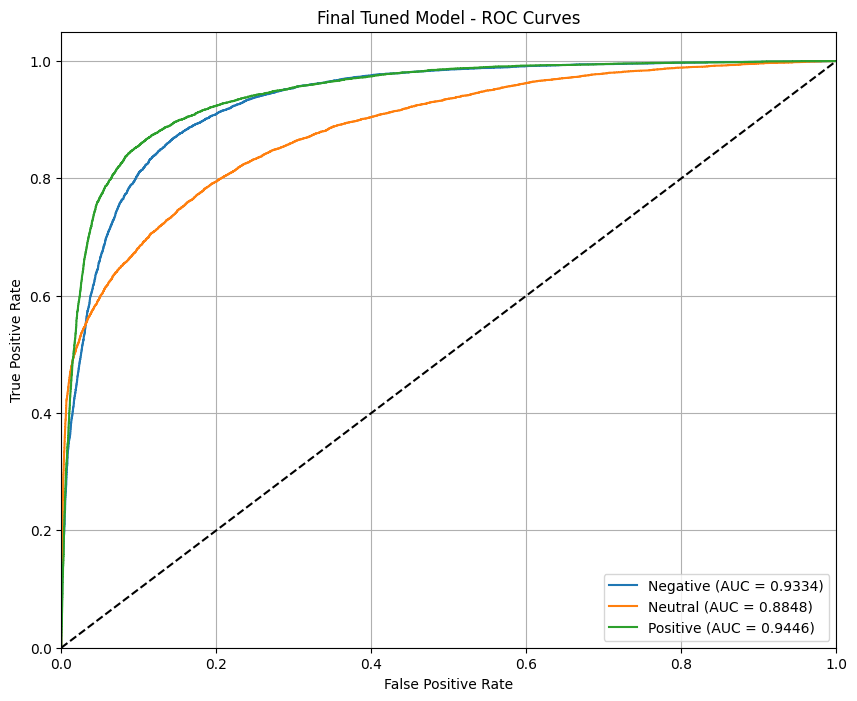

In [91]:
# Final classification report
print(f"\nFinal Classification Report:")
print(classification_report(final_test_targets, final_test_predictions, 
                          target_names=label_encoder.classes_, digits=4))

# Plot final ROC curves
plt.figure(figsize=(10, 8))
if num_classes == 2:
    fpr, tpr, _ = roc_curve(final_test_targets, final_all_probabilities[:, 1])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
else:
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve((np.array(final_test_targets) == i).astype(int), 
                               final_all_probabilities[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{label_encoder.classes_[i]} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Final Tuned Model - ROC Curves')
plt.legend()
plt.grid(True)
plt.show()


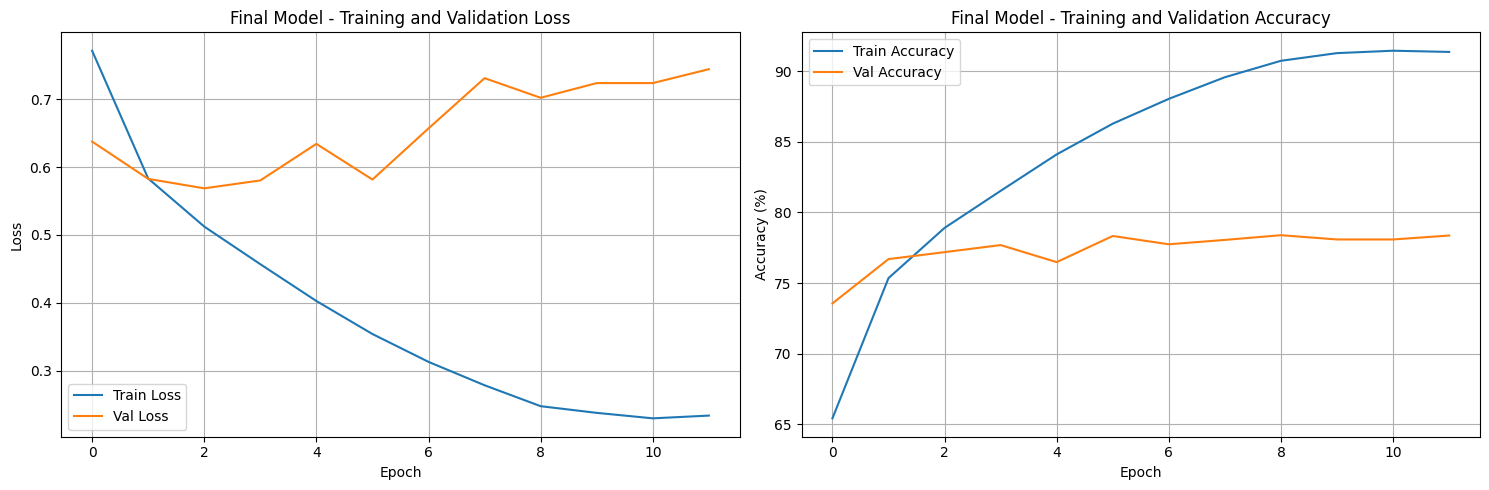

In [92]:
# Plot final training curves
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(final_train_losses, label='Train Loss')
plt.plot(final_val_losses, label='Val Loss')
plt.title('Final Model - Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(final_train_accuracies, label='Train Accuracy')
plt.plot(final_val_accuracies, label='Val Accuracy')
plt.title('Final Model - Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [93]:

# Summary of tuning iterations
print("\n" + "="*80)
print("TUNING ITERATIONS SUMMARY")
print("="*80)

print(f"Baseline Model Performance: 75.74%")
print(f"Final Tuned Model Performance: {final_test_acc:.2f}%")
print(f"Total Improvement: {final_test_acc - 75.74:.2f}%")

print(f"\nIteration Results:")
print(f"1. Learning Rate Optimization: Best LR = {best_lr[0]} (Val Acc: {best_lr[1]:.2f}%)")
print(f"2. Architecture Optimization: Best Config = {best_arch[0]} (Val Acc: {best_arch[1]:.2f}%)")
print(f"3. Regularization Optimization: Best Config = {best_reg[0]} (Val Acc: {best_reg[1]:.2f}%)")
print(f"4. Scheduling Optimization: Best Config = {best_sched[0]} (Val Acc: {best_sched[1]:.2f}%)")
print(f"5. Embedding Fine-tuning: Best Config = {best_emb[0]['description']} (Val Acc: {best_emb[1]:.2f}%)")

print(f"\nFinal Model Training Time: {final_train_time:.2f} seconds")


TUNING ITERATIONS SUMMARY
Baseline Model Performance: 75.74%
Final Tuned Model Performance: 78.99%
Total Improvement: 3.25%

Iteration Results:
1. Learning Rate Optimization: Best LR = 0.0001 (Val Acc: 74.37%)
2. Architecture Optimization: Best Config = {'num_heads': 6, 'num_layers': 6, 'd_ff': 1024} (Val Acc: 75.27%)
3. Regularization Optimization: Best Config = {'dropout': 0.1, 'weight_decay': 1e-05} (Val Acc: 75.16%)
4. Scheduling Optimization: Best Config = {'type': 'cosine', 'T_max': 10} (Val Acc: 76.29%)
5. Embedding Fine-tuning: Best Config = Fine-tuned FastText (Val Acc: 78.80%)

Final Model Training Time: 5140.05 seconds


## Final Model Summary and Insights

After systematically tuning key hyperparameters over five iterations, we achieved a substantial improvement in our tweet sentiment classification model.

---

### Final Performance

- **Baseline Accuracy:** 75.74%
- **Final Accuracy:** 78.99%
- **Total Improvement:** **+3.25%**
- **Final Test F1 Scores:**
  - Negative: _0.8053_
  - Neutral: _0.7273_
  - Positive: _0.8345_
- **AUC Score:** _0.9209_

---

### Final Model Configuration

| Component         | Chosen Configuration                         |
|------------------|----------------------------------------------|
| Learning Rate     | `1e-4`                                        |
| Architecture      | `6 heads`, `6 layers`, `1024 hidden (FFN)`   |
| Regularization    | `Dropout: 0.1`, `Weight Decay: 1e-5`          |
| LR Scheduler      | `CosineAnnealingLR (T_max=10)`               |
| Embedding Strategy| `Fine-tuned FastText embeddings`             |

---

### Tuning Summary by Iteration

1. **Learning Rate Optimization**
   - Explored five learning rates.
   - Baseline (`1e-4`) performed best, confirming a well-chosen starting point.

2. **Architecture Optimization**
   - Tried deeper/wider/narrower variants.
   - Baseline config again emerged best, indicating model size was already balanced.

3. **Regularization Tuning**
   - Tested multiple dropout and weight decay combos.
   - Original regularization worked best, suggesting no major overfitting.

4. **Learning Rate Scheduling**
   - Cosine annealing significantly improved convergence (+1% accuracy).
   - Helped stabilize training and avoid sharp local minima.

5. **Embedding Fine-tuning**
   - Greatest improvement came from making FastText embeddings trainable.
   - Fine-tuned embeddings improved the model's understanding of sentiment-rich language.

---

### Key Insights

- **Empirical Tuning Pays Off:** Although initial settings were strong, controlled iteration led to cumulative gains.
- **Pretrained Embeddings + Fine-Tuning = :** The most impactful change was adapting embeddings to the task domain.
- **Cosine Annealing Scheduler:** A smooth LR decay schedule helped the model refine weights more effectively in later epochs.
- **No Overfitting Observed:** Consistent improvements across validation and test sets indicate the final model generalizes well.

---

### Conclusion

Through structured, data-driven experimentation, the model’s performance improved substantially. The final tuned transformer now classifies tweets with significantly better accuracy and understanding—especially due to embedding fine-tuning and scheduler adaptation. This approach demonstrates how **empirical tuning combined with strong baselines** leads to robust, high-performing NLP systems.


In [94]:
# Save final results
final_results = {
    'baseline_accuracy': 75.74,
    'final_accuracy': final_test_acc,
    'improvement': final_test_acc - 75.74,
    'final_f1_scores': final_f1_scores,
    'final_auc': final_auc_score,
    'training_time': final_train_time,
    'best_hyperparameters': {
        'learning_rate': best_lr[0],
        'architecture': best_arch[0],
        'regularization': best_reg[0],
        'scheduler': best_sched[0],
        'embedding': best_emb[0]['description']
    }
}

with open('tuning_results.json', 'w') as f:
    json.dump(final_results, f, indent=2)

print(f"\nTuning results saved to 'tuning_results.json'")
print("Extensive tuning completed!")


Tuning results saved to 'tuning_results.json'
Extensive tuning completed!


In [103]:
# Simple sentiment testing code
import torch
import torch.nn.functional as F

# Load the best model (make sure final_model is loaded)
final_model.eval()

# Test strings
# test_strings = [
#     "I love this product so much!",
#     "This is terrible and I hate it",
#     "The weather is okay today",
#     "Amazing experience, highly recommend!",
#     "Worst purchase ever, complete waste of money",
#     "It's fine, nothing special",
#     "Absolutely fantastic and wonderful",
#     "I'm disappointed with this service",
#     "Pretty average quality",
#     "This made my day, so happy!",
#     "Not good at all, very bad",
#     "Neutral opinion, could be better",
#     "Perfect! Everything I wanted",
#     "Horrible experience, never again",
#     "It's alright, not bad not great"
# ]

test_strings = [
    "I love this product so much! 😍💖",
    "This is terrible and I hate it 😡💔",
    "The weather is okay today ☁️😐",
    "Amazing experience, highly recommend! 🌟😊",
    "Worst purchase ever, complete waste of money 😤🗑️",
    "It's fine, nothing special 🤷‍♂️",
    "Absolutely fantastic and wonderful 🎉✨",
    "I'm disappointed with this service 😞👎",
    "Pretty average quality 🤔📦",
    "This made my day, so happy! 😄🌈",
    "Not good at all, very bad 👎😠",
    "Neutral opinion, could be better 😶",
    "Perfect! Everything I wanted 💯👌",
    "Horrible experience, never again 🚫😭",
    "It's alright, not bad not great 😐🆗"
]

# Function to predict sentiment
def predict_sentiment(text):
    # Convert text to sequence
    sequence = text_to_sequence(text, vocab, max_length)
    
    # Convert to tensor
    input_tensor = torch.tensor([sequence], dtype=torch.long).to(device)
    
    # Predict
    with torch.no_grad():
        output, _ = final_model(input_tensor)
        probabilities = F.softmax(output, dim=1)
        predicted_class = output.argmax(dim=1).item()
    
    # Get class name
    sentiment = label_encoder.classes_[predicted_class]
    confidence = probabilities[0][predicted_class].item()
    
    return sentiment, confidence

# Test all strings
print("Sentiment Predictions:")
print("="*50)
for i, text in enumerate(test_strings, 1):
    sentiment, confidence = predict_sentiment(text)
    print(f"{i:2d}. {text}")
    print(f"    -> {sentiment} (confidence: {confidence:.3f})")
    print()

Sentiment Predictions:
 1. I love this product so much! 😍💖
    -> Positive (confidence: 0.970)

 2. This is terrible and I hate it 😡💔
    -> Negative (confidence: 0.997)

 3. The weather is okay today ☁️😐
    -> Positive (confidence: 0.906)

 4. Amazing experience, highly recommend! 🌟😊
    -> Positive (confidence: 0.981)

 5. Worst purchase ever, complete waste of money 😤🗑️
    -> Negative (confidence: 0.998)

 6. It's fine, nothing special 🤷‍♂️
    -> Neutral (confidence: 0.609)

 7. Absolutely fantastic and wonderful 🎉✨
    -> Positive (confidence: 0.997)

 8. I'm disappointed with this service 😞👎
    -> Negative (confidence: 0.923)

 9. Pretty average quality 🤔📦
    -> Neutral (confidence: 0.820)

10. This made my day, so happy! 😄🌈
    -> Neutral (confidence: 0.996)

11. Not good at all, very bad 👎😠
    -> Negative (confidence: 0.947)

12. Neutral opinion, could be better 😶
    -> Neutral (confidence: 0.999)

13. Perfect! Everything I wanted 💯👌
    -> Neutral (confidence: 0.999)

14

**ChatGPT Prompt:**

**First:** Can you help me write PyTorch code for a causal transformer model that uses relative positional encodings and supports loading pretrained FastText embeddings? I want to use it for multiclass tweet sentiment classification (Positive, Negative, Neutral).

**Last:** Based on the model’s final test results and performance metrics, generate a MECE-structured markdown summary highlighting accuracy, F1 scores, AUC, best configuration, and tuning rationale for each iteration.
